### Read the SNOWPACK TKG4 WY2024 Simulations

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **xarray**

In [2]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [3]:
pwd

'/home/cassie/python/repos/snow_model_forcing/sites/tkg4'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [4]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [5]:
ds_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2024_heatflux_soiltemp_zero.smet")

print(ds_snowpack)
print(header)

<xarray.Dataset> Size: 4MB
Dimensions:               (timestamp: 7317)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 59kB 2023-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 59kB 5.416 1.237 ... 0.679 2.729
    Ql                    (timestamp) float64 59kB -6.318 -0.443 ... 0.511 1.08
    Qg                    (timestamp) float64 59kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 59kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 59kB 3.073 2.183 1.734 ... 0.0 0.0
    Qr                    (timestamp) float64 59kB 0.0 0.0 0.0 ... 0.0 1.06
    ...                    ...
    zSs                   (timestamp) float64 59kB 2.661 5.156 ... 350.7 350.7
    Ss                    (timestamp) float64 59kB 6.0 6.0 6.0 ... 0.584 0.497
    zS4                   (timestamp) float64 59kB 2.661 5.156 ... 350.7 350.7
    S4                    (timestamp) float64 59kB 6.0 6.0 6.0 ... 2.

/tmp/ipykernel_3190753/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

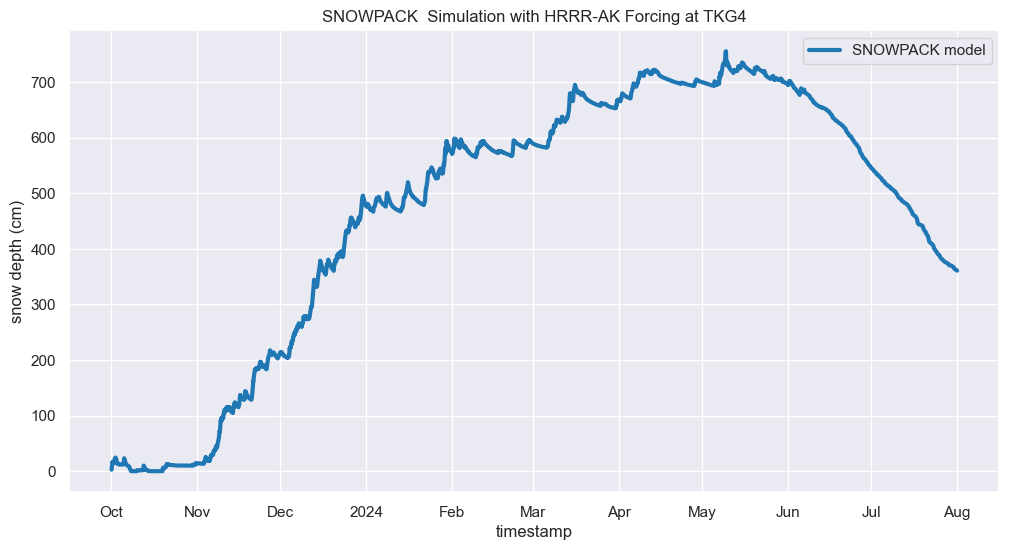

In [8]:
ds_snowpack.HS_mod.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK  Simulation with HRRR-AK Forcing at TKG4')
plt.legend()

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

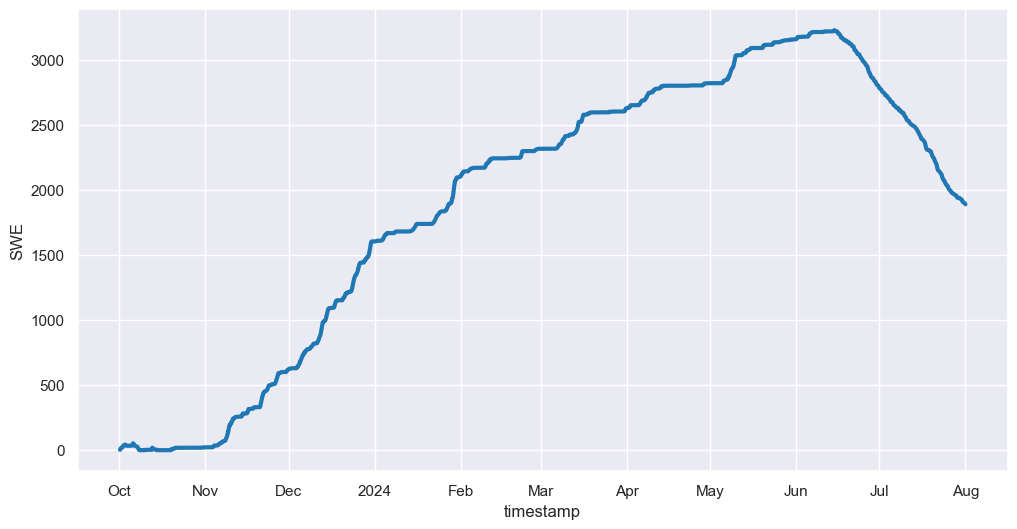

In [11]:
# plot SWE 
ds_snowpack.SWE.plot(label = 'SNOWPACK model', linewidth = 3, color='tab:blue')